# Descoberta de tópicos, NER e classificação com BERTimbau

Este notebook é um projeto de descoberta de tópicos, NER e classificação de textos usando o BERTimbau, aplicado a dados do DL_2024 https://www.kaggle.com/datasets/georgekurokijr/dl-2024

Aplicamos técnicas de NLP com Transformers a um conjunto de textos de projetos científicos e tecnológicos em português. O objetivo é descobrir automaticamente os temas presentes nos textos, identificar entidades nomeadas (pessoas, organizações, locais) e refinar essa descoberta de temas por meio de fine-tuning do BERTimbau.

## 1. Instalação das dependências

Esta seção instala as bibliotecas necessárias: `transformers` (para carregar o BERTimbau), `accelerate`, `spacy`, `scikit-learn`, `pandas` e `numpy`. Também baixa o modelo de reconhecimento de entidades nomeadas (NER) pré-treinado do spaCy para português, o `pt_core_news_sm`, que será usado mais adiante. Se estiver rodando no Kaggle, é necessário habilitar a opção "Internet" nas configurações do notebook para que os downloads funcionem.



In [1]:
!pip -q install transformers accelerate spacy scikit-learn pandas numpy matplotlib
!python -m spacy download pt_core_news_sm -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 84.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2. Configuração central

Aqui ficam concentrados todos os parâmetros importantes do experimento, para facilitar ajustes sem precisar mexer no restante do código:

- **`MODEL_NAME`**: define qual modelo pré-treinado será usado — o BERTimbau (`neuralmind/bert-base-portuguese-cased`), um BERT treinado especificamente em português.
- **`MAX_LEN`**: número máximo de tokens que cada texto pode ter ao ser processado pelo modelo.
- **`N_AMOSTRAS`**: como o dataset real tem cerca de 2700 textos, e treinar + gerar visualizações a cada época pode ser demorado, usa-se por padrão uma subamostra de 500 textos. É possível trocar para `None` para usar o dataset inteiro.
- **`EPOCHS`, `BATCH_SIZE`, `LEARNING_RATE`**: hiperparâmetros do fine-tuning do modelo.
- **`MIN_K`, `MAX_K`**: faixa de números de clusters testados na descoberta de tópicos.
- **`N_TOPICOS_FIXO`**: por padrão `None`, deixando o número de tópicos ser escolhido automaticamente pelo silhouette score; pode ser definido manualmente se desejado.

Essa célula também define a semente aleatória (`RANDOM_STATE`) para garantir reprodutibilidade e detecta se há GPU disponível.



In [1]:
import os
import random
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# CONFIG

RANDOM_STATE = 42                 # semente para reprodutibilidade

MODEL_NAME = "neuralmind/bert-base-portuguese-cased"  # BERTimbau
MAX_LEN = 128                     # textos reais são mais longos que as frases sintéticas

N_AMOSTRAS = 500                  # subamostra p/ runtime; None = usa o dataset inteiro (~2700 textos)
EPOCHS = 6                        # nº de épocas de fine-tuning (= nº de "fotos" do t-SNE, + a foto inicial)
BATCH_SIZE = 16                   # tamanho do lote de treino
LEARNING_RATE = 2e-5              # taxa de aprendizado do fine-tuning

MIN_K = 3                         # nº mínimo de tópicos/clusters testado
MAX_K = 10                        # nº máximo de tópicos/clusters testado
N_TOPICOS_FIXO = None             # defina um inteiro para forçar o nº de tópicos; None = automático

OUTPUT_ENCODING = "utf-8"         # troque para "latin-1" se for integrar com arquivos legados

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


Usando dispositivo: cuda


## 3. Carregamento e limpeza dos dados

Nesta etapa, o arquivo `dadosTextosCientificos.tsv` é carregado — um arquivo com as colunas `Título_Público` e `Descricao_pública`. Como é um dado real, ele exige alguns cuidados:

- Está salvo em codificação **Windows-1252 (cp1252)**, não em UTF-8, então precisa ser lido com o encoding correto para não corromper acentuação.
- Existem linhas com título ou descrição vazios (`NaN`), que são removidas.
- Existem títulos duplicados no arquivo.

Depois da limpeza, título e descrição são combinados em um único campo `texto`, que servirá como entrada para o BERTimbau nas etapas seguintes.

In [3]:
CAMINHOS_POSSIVEIS = [
    "/kaggle/input/dados-textos-cientificos/dadosTextosCientificos.tsv",
    "/kaggle/input/dadostextoscientificos/dadosTextosCientificos.tsv",
    "dadosTextosCientificos.tsv",
]

caminho_tsv = next((p for p in CAMINHOS_POSSIVEIS if os.path.exists(p)), CAMINHOS_POSSIVEIS[-1])
print("Lendo arquivo:", caminho_tsv)

# O arquivo original foi salvo em Windows-1252 (cp1252), não em UTF-8.
df_textos = pd.read_csv(caminho_tsv, sep="\t", encoding="cp1252")
df_textos.columns = ["titulo", "descricao"]

print("Linhas brutas:", len(df_textos))
display(df_textos.head(3))


Lendo arquivo: dadosTextosCientificos.tsv
Linhas brutas: 2725


,titulo,descricao
0,Açúcar de frutas e aplicação em bolos como sub...,O uso de inovações tecnológicas auxilia as ind...
1,Desenvolver uma linha de farofas com castanhas...,O uso de inovações tecnológicas auxilia as ind...
2,Desenvolvimento de cobertura líquida para sorvete,O Brasil é considerado um país com a maior bio...


In [4]:
# Limpeza: remove nulos, aparas de espaço, textos curtos demais e duplicatas.
df_textos = df_textos.dropna(subset=["titulo", "descricao"]).copy()
df_textos["titulo"] = df_textos["titulo"].str.strip()
df_textos["descricao"] = df_textos["descricao"].str.strip()

df_textos = df_textos[
    (df_textos["titulo"].str.len() > 3) & (df_textos["descricao"].str.len() > 20)
]

df_textos["texto"] = df_textos["titulo"] + ". " + df_textos["descricao"]
df_textos = df_textos.drop_duplicates(subset=["texto"]).reset_index(drop=True)

# Amostragem, se configurada (ver célula de CONFIG).
if N_AMOSTRAS is not None and N_AMOSTRAS < len(df_textos):
    df_textos = df_textos.sample(n=N_AMOSTRAS, random_state=RANDOM_STATE).reset_index(drop=True)

df_textos["indice_original"] = df_textos.index

print("Linhas após limpeza / amostragem:", len(df_textos))
print("Tamanho médio do texto (caracteres):", round(df_textos["texto"].str.len().mean(), 1))
display(df_textos[["titulo", "descricao"]].head(5))


Linhas após limpeza / amostragem: 500
Tamanho médio do texto (caracteres): 397.8


,titulo,descricao
0,JIRo – Joint Inspection Robot,Desenvolvimento de um protótipo de robô para l...
1,Produção de proteína S de SARS-COV-2 para dese...,O projeto tem como objetivo otimizar e escalon...
2,Validação de um software inteligente para otim...,"Este projeto visa a validação, homologação e a..."
3,Desenvolvimento de Unidade de geração de energ...,Desenvolvimento de uma plataforma para geração...
4,AI-ML QA,Pesquisar e desenvolver metodologia e soluções...


## 4. Reconhecimento de Entidades Nomeadas (NER) com modelo pré-treinado

Usa-se o modelo de NER já treinado do spaCy para português (`pt_core_news_sm`) para identificar automaticamente entidades nos textos, como pessoas (`PER`), organizações (`ORG`), locais (`LOC`) e outras categorias (`MISC`). Isso permite extrair, por exemplo, siglas de programas, nomes de instituições e localidades (estados, biomas, cidades) mencionadas nos projetos. Em seguida, analisa-se quais entidades específicas aparecem com mais frequência no conjunto de textos.

In [5]:
import spacy

nlp_ner_pt = spacy.load("pt_core_news_sm")

registros_entidades = []
for idx, doc in zip(
    df_textos["indice_original"],
    nlp_ner_pt.pipe(df_textos["texto"], batch_size=32),
):
    for ent in doc.ents:
        registros_entidades.append({
            "indice_texto": idx,
            "entidade": ent.text,
            "tipo": ent.label_,
            "inicio": ent.start_char,
            "fim": ent.end_char,
        })

df_entidades = pd.DataFrame(registros_entidades)
print("Total de entidades extraídas:", len(df_entidades))
display(df_entidades["tipo"].value_counts())
display(df_entidades.head(10))


Total de entidades extraídas: 1452


,count
tipo,
MISC,613
LOC,367
ORG,258
PER,214


,indice_texto,entidade,tipo,inicio,fim
0,0,JIRo,MISC,0,4
1,0,Joint Inspection Robot,MISC,7,29
2,0,FPSOs,LOC,178,183
3,1,S de SARS-COV-2,MISC,21,36
4,1,S do coronavírus SARS-COV-2,MISC,181,208
5,1,COVID-19,LOC,291,299
6,1,COVID-19,LOC,378,386
7,1,ANVISA,MISC,453,459
8,4,AI-ML QA,MISC,0,8
9,4,Inteligência Artificial,MISC,111,134


Como curiosidade, vale olhar quais entidades específicas aparecem com mais frequência no
acervo — normalmente siglas de programas, órgãos e locais recorrentes nos projetos.


In [6]:
top_entidades = (
    df_entidades
    .groupby(["tipo", "entidade"])
    .size()
    .reset_index(name="contagem")
    .sort_values("contagem", ascending=False)
    .head(20)
)
display(top_entidades)


,tipo,entidade,contagem
59,LOC,Desenvolver,43
422,MISC,Inteligência Artificial,14
25,LOC,Brasil,14
106,LOC,IA,12
882,ORG,PAKS,7
710,MISC,Wi-Fi,6
1138,PER,sera?o,6
427,MISC,Internet das Coisas,6
28,LOC,COVID-19,6
433,MISC,IoT,6


## 5. Descoberta automática de tópicos com embeddings do BERTimbau

Como os textos não têm um rótulo de tema conhecido, os temas precisam ser "descobertos". Para isso:

1. Extrai-se o embedding de cada texto usando o BERTimbau **congelado** (sem nenhum treinamento ainda, apenas extraindo representações vetoriais).
2. Aplica-se o algoritmo KMeans sobre esses embeddings, testando diferentes valores de *k* (número de clusters).
3. O melhor valor de *k* é escolhido com base no **silhouette score**, uma métrica que mede o quão bem separados estão os clusters.

Como o dataset é real e heterogêneo — com vocabulário técnico variado e poucos textos por assunto específico — é esperado que o silhouette score seja relativamente baixo, já que os temas "de verdade" tendem a se misturar mais do que em um cenário artificial.

Com o número de tópicos definido, roda-se o KMeans final para gerar o **pseudo-rótulo de tema** de cada texto. Cada tópico recebe um "nome" com base nos termos mais característicos (via TF-IDF) dos textos daquele grupo.


In [7]:
from transformers import AutoModel, AutoTokenizer
import torch.nn as nn

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert_congelado = AutoModel.from_pretrained(MODEL_NAME).to(device)
bert_congelado.eval()


def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


# Pré-tokeniza todo o dataset uma única vez; esses tensores também serão reaproveitados
# no fine-tuning da seção 6.
encoded_all = tokenizer(
    df_textos["texto"].tolist(),
    padding="max_length",
    truncation=True,
    max_length=MAX_LEN,
    return_tensors="pt",
)
input_ids_all = encoded_all["input_ids"]
attention_mask_all = encoded_all["attention_mask"]

print("input_ids:", input_ids_all.shape)


config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


input_ids: torch.Size([500, 128])


In [8]:
def extrair_embeddings_congelados(input_ids, attention_mask, batch_size=BATCH_SIZE):
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(input_ids), batch_size):
            ids = input_ids[start:start + batch_size].to(device)
            mask = attention_mask[start:start + batch_size].to(device)
            out = bert_congelado(input_ids=ids, attention_mask=mask)
            pooled = mean_pooling(out.last_hidden_state, mask)
            embeddings.append(pooled.cpu().numpy())
    return np.vstack(embeddings)


embeddings_congelados = extrair_embeddings_congelados(input_ids_all, attention_mask_all)
print("Shape dos embeddings congelados (BERTimbau, sem fine-tuning):", embeddings_congelados.shape)


Shape dos embeddings congelados (BERTimbau, sem fine-tuning): (500, 768)


,k,silhouette
0,3,0.053458
1,4,0.060584
2,5,0.060469
3,6,0.052756
4,7,0.054016
5,8,0.062794
6,9,0.053076
7,10,0.038278


Número de tópicos escolhido pelo silhouette: 8


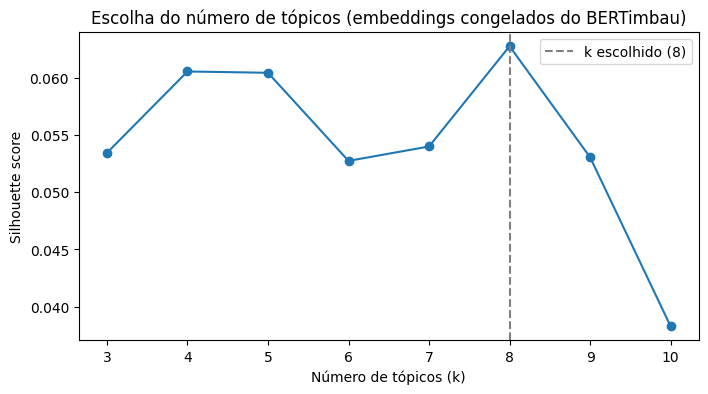

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

n_samples = len(df_textos)
max_k_adjusted = min(MAX_K, n_samples - 1)

silhouette_results = []
for k in range(MIN_K, max_k_adjusted + 1):
    km_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels_tmp = km_tmp.fit_predict(embeddings_congelados)
    score = silhouette_score(embeddings_congelados, labels_tmp)
    silhouette_results.append({"k": k, "silhouette": score})

silhouette_df = pd.DataFrame(silhouette_results)
display(silhouette_df)

if N_TOPICOS_FIXO is not None:
    best_k = N_TOPICOS_FIXO
    print("Número de tópicos fixado manualmente em CONFIG:", best_k)
else:
    best_k = int(silhouette_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
    print("Número de tópicos escolhido pelo silhouette:", best_k)

plt.figure(figsize=(8, 4))
plt.plot(silhouette_df["k"], silhouette_df["silhouette"], marker="o")
plt.axvline(best_k, color="gray", linestyle="--", label=f"k escolhido ({best_k})")
plt.xlabel("Número de tópicos (k)")
plt.ylabel("Silhouette score")
plt.title("Escolha do número de tópicos (embeddings congelados do BERTimbau)")
plt.legend()
plt.show()


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

STOPWORDS_PT = [
    "a", "o", "as", "os", "um", "uma", "uns", "umas",
    "de", "do", "da", "dos", "das", "em", "no", "na", "nos", "nas",
    "por", "pelo", "pela", "pelos", "pelas", "para", "pra", "com", "sem", "sob", "sobre",
    "entre", "até", "após", "antes", "desde", "contra", "perante",
    "e", "ou", "mas", "porém", "contudo", "todavia", "porque", "pois", "que", "se",
    "quando", "enquanto", "como", "conforme", "embora", "caso",
]

vectorizer_topicos = TfidfVectorizer(
    max_features=3000,
    stop_words=STOPWORDS_PT,
    ngram_range=(1, 2),
    min_df=2,
    lowercase=True,
    strip_accents="unicode",
)
tfidf_topicos = vectorizer_topicos.fit_transform(df_textos["texto"])
terms_topicos = np.array(vectorizer_topicos.get_feature_names_out())

kmeans_topicos = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init="auto")
df_textos["tema_pseudo_id"] = kmeans_topicos.fit_predict(embeddings_congelados)

nomes_temas = {}
for tid in sorted(df_textos["tema_pseudo_id"].unique()):
    indices = df_textos.index[df_textos["tema_pseudo_id"] == tid]
    media_tfidf = np.asarray(tfidf_topicos[indices].mean(axis=0)).ravel()
    top_termos = terms_topicos[media_tfidf.argsort()[::-1][:3]]
    nomes_temas[tid] = " / ".join(top_termos)

df_textos["tema_pseudo_nome"] = df_textos["tema_pseudo_id"].map(nomes_temas)
NOMES_TEMAS = [nomes_temas[i] for i in sorted(nomes_temas)]

print("Tópicos descobertos automaticamente:")
for tid, nome in nomes_temas.items():
    qtd = (df_textos["tema_pseudo_id"] == tid).sum()
    print(f"  Tópico {tid} ({qtd} textos): {nome}")


Tópicos descobertos automaticamente:
  Tópico 0 (49 textos): producao / tratamento / controle
  Tópico 1 (28 textos): sistema / desenvolvimento / armazenamento energia
  Tópico 2 (175 textos): projeto / desenvolvimento / sistema
  Tópico 3 (34 textos): desenvolvimento / projeto / producao
  Tópico 4 (96 textos): software / plataforma / desenvolvimento
  Tópico 5 (79 textos): desenvolvimento / processo / ao
  Tópico 6 (8 textos): es / medic / ncia
  Tópico 7 (31 textos): desenvolver / rota / desenvolvimento


## 6. Fine-tuning do BERTimbau como classificador dos tópicos + separação progressiva no t-SNE

Com os pseudo-temas definidos na etapa anterior, o BERTimbau passa por um **fine-tuning leve** para aprender a classificar cada texto em seu respectivo tópico. Durante o treinamento, é tirada uma "fotografia" dos embeddings (por meio de uma projeção t-SNE) antes do treino e após cada época. O objetivo é visualizar, de forma progressiva, o modelo aprendendo a separar melhor os grupos que ele mesmo descobriu na etapa 5.

O gráfico de separação progressiva mostra um conjunto de projeções t-SNE, uma por "fotografia", com os pontos coloridos pelo pseudo-tema de cada texto — permitindo observar se a separação entre os grupos fica mais nítida e compacta a cada época.

A curva de loss/acurácia do treinamento complementa essa visualização de forma numérica, mostrando se o modelo está de fato aprendendo a separar os tópicos.

In [11]:
class TemaClassifier(nn.Module):
    """BERTimbau + cabeça linear de classificação sobre o embedding (mean pooling)."""

    def __init__(self, model_name, n_classes):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = mean_pooling(outputs.last_hidden_state, attention_mask)
        logits = self.classifier(self.dropout(pooled))
        return logits, pooled


model = TemaClassifier(MODEL_NAME, n_classes=best_k).to(device)
labels_all = torch.tensor(df_textos["tema_pseudo_id"].values, dtype=torch.long)
print("Modelo carregado em:", device, "| nº de classes:", best_k)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo carregado em: cuda | nº de classes: 8


In [12]:
from sklearn.manifold import TSNE

PERPLEXITY = min(30, max(5, (n_samples - 1) // 3))


def extrair_embeddings(model, input_ids, attention_mask, batch_size=BATCH_SIZE):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(input_ids), batch_size):
            ids = input_ids[start:start + batch_size].to(device)
            mask = attention_mask[start:start + batch_size].to(device)
            _, pooled = model(ids, mask)
            embeddings.append(pooled.cpu().numpy())
    return np.vstack(embeddings)


snapshots = []  # cada item: {"rotulo": str, "embeddings": np.array, "pontos_2d": np.array}


def tirar_fotografia(rotulo):
    embeddings = extrair_embeddings(model, input_ids_all, attention_mask_all)
    tsne = TSNE(
        n_components=2,
        perplexity=PERPLEXITY,
        learning_rate="auto",
        init="pca",
        random_state=RANDOM_STATE,
    )
    pontos_2d = tsne.fit_transform(embeddings)
    snapshots.append({"rotulo": rotulo, "embeddings": embeddings, "pontos_2d": pontos_2d})
    return embeddings


# Fotografia 0: embeddings do BERTimbau ainda sem nenhum fine-tuning para os tópicos.
_ = tirar_fotografia("Antes do treino (época 0)")
print("Fotografia inicial registrada.")


Fotografia inicial registrada.


In [13]:
optimizer_ft = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

history = {"loss": [], "acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(len(input_ids_all))
    total_loss, correct = 0.0, 0

    for start in range(0, len(perm), BATCH_SIZE):
        idx = perm[start:start + BATCH_SIZE]
        ids = input_ids_all[idx].to(device)
        mask = attention_mask_all[idx].to(device)
        labels_batch = labels_all[idx].to(device)

        optimizer_ft.zero_grad()
        logits, _ = model(ids, mask)
        loss = criterion(logits, labels_batch)
        loss.backward()
        optimizer_ft.step()

        total_loss += loss.item() * len(idx)
        correct += (logits.argmax(dim=1) == labels_batch).sum().item()

    avg_loss = total_loss / len(perm)
    acc = correct / len(perm)
    history["loss"].append(avg_loss)
    history["acc"].append(acc)
    print(f"Época {epoch}/{EPOCHS} — loss: {avg_loss:.4f} — acurácia: {acc:.3f}")

    tirar_fotografia(f"Época {epoch}")

print("Treinamento concluído. Fotografias coletadas:", len(snapshots))


Época 1/6 — loss: 1.6089 — acurácia: 0.438
Época 2/6 — loss: 0.7482 — acurácia: 0.786
Época 3/6 — loss: 0.2995 — acurácia: 0.922
Época 4/6 — loss: 0.1055 — acurácia: 0.982
Época 5/6 — loss: 0.0356 — acurácia: 1.000
Época 6/6 — loss: 0.0174 — acurácia: 1.000
Treinamento concluído. Fotografias coletadas: 7


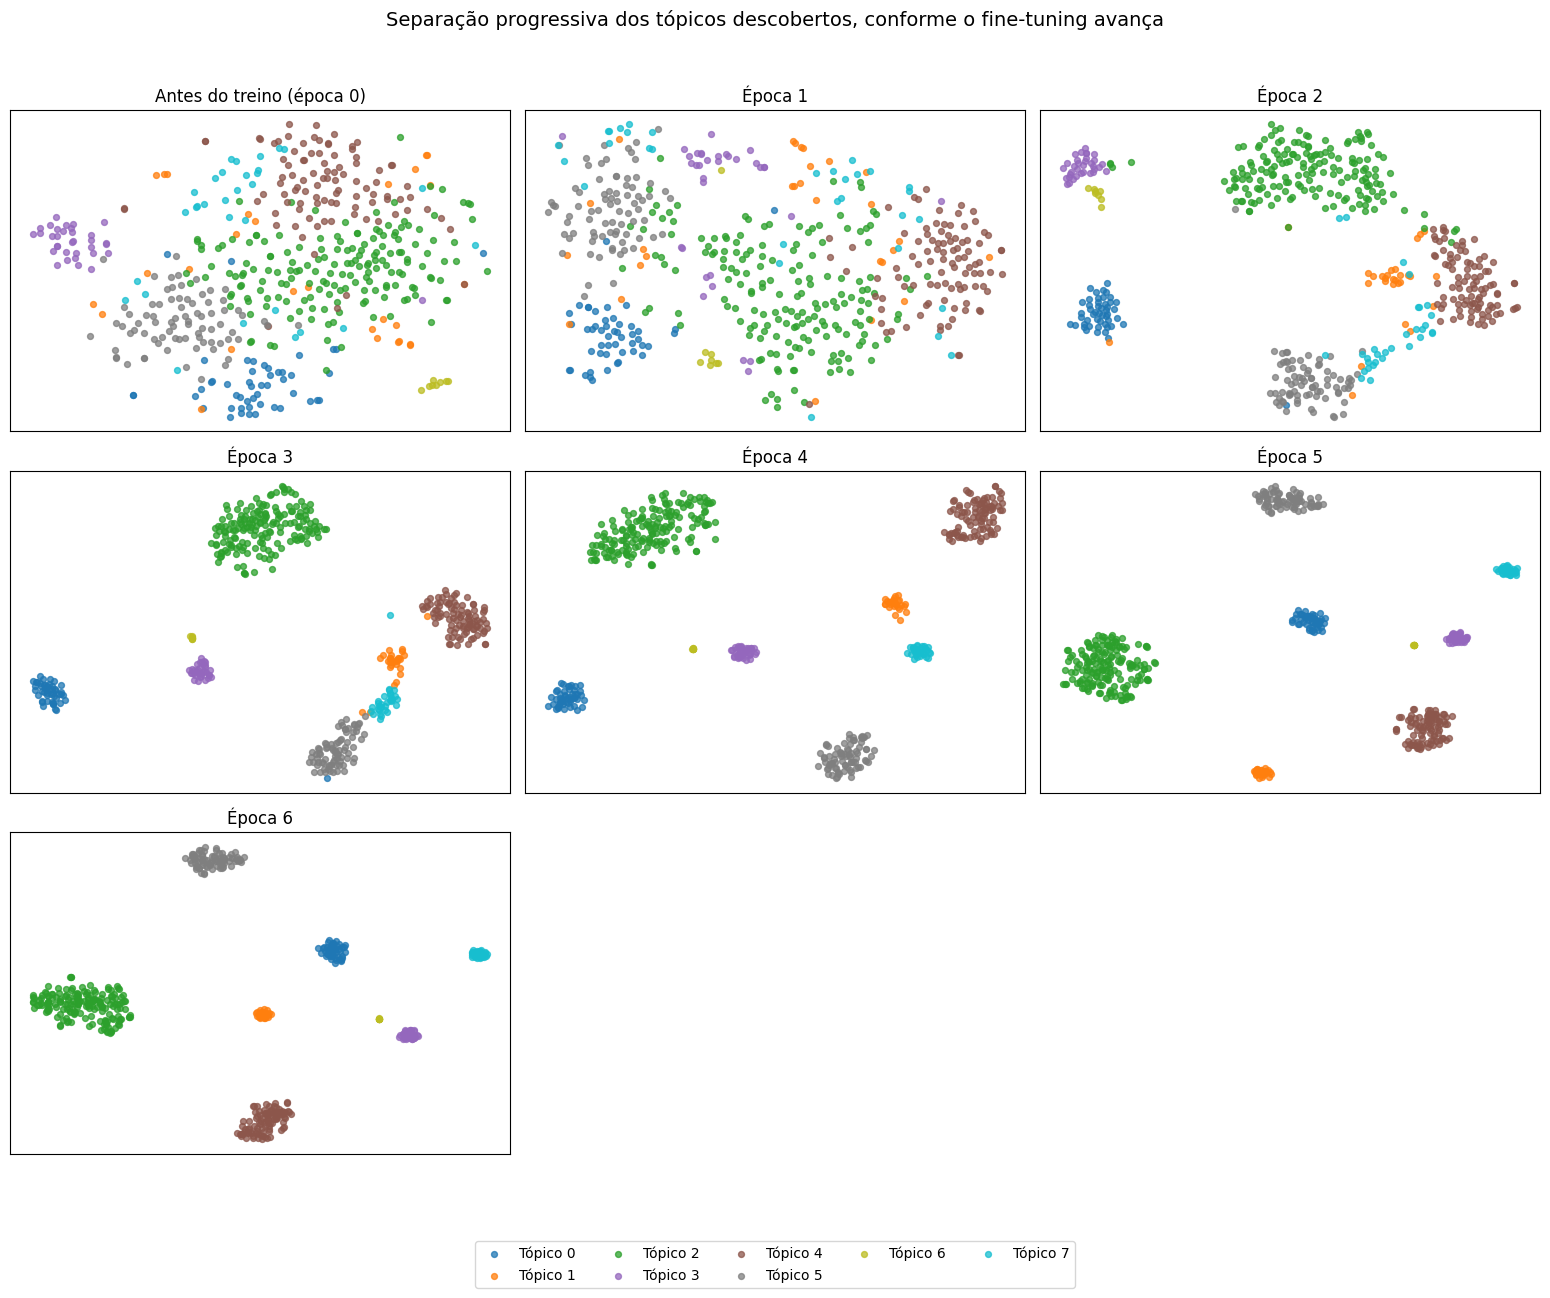

In [14]:
import math

cores = plt.cm.tab10(np.linspace(0, 1, len(NOMES_TEMAS)))

n_snap = len(snapshots)
ncols = 3
nrows = math.ceil(n_snap / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.2 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, snap in enumerate(snapshots):
    ax = axes[i]
    pontos = snap["pontos_2d"]
    for tema_id in sorted(df_textos["tema_pseudo_id"].unique()):
        mascara = labels_all.numpy() == tema_id
        ax.scatter(pontos[mascara, 0], pontos[mascara, 1],
                   label=f"Tópico {tema_id}", alpha=0.75, s=18, color=cores[tema_id])
    ax.set_title(snap["rotulo"])
    ax.set_xticks([])
    ax.set_yticks([])

for j in range(len(snapshots), len(axes)):
    fig.delaxes(axes[j])

handles, labels_legend = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_legend, loc="lower center", ncol=min(len(NOMES_TEMAS), 5), bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Separação progressiva dos tópicos descobertos, conforme o fine-tuning avança", fontsize=14)
plt.tight_layout(rect=[0, 0.06, 1, 0.96])
plt.show()


Curva de loss/acurácia do fine-tuning, para acompanhar numericamente o que o gráfico de
t-SNE já mostrou visualmente: o modelo está de fato aprendendo a separar os tópicos que
ele mesmo descobriu?


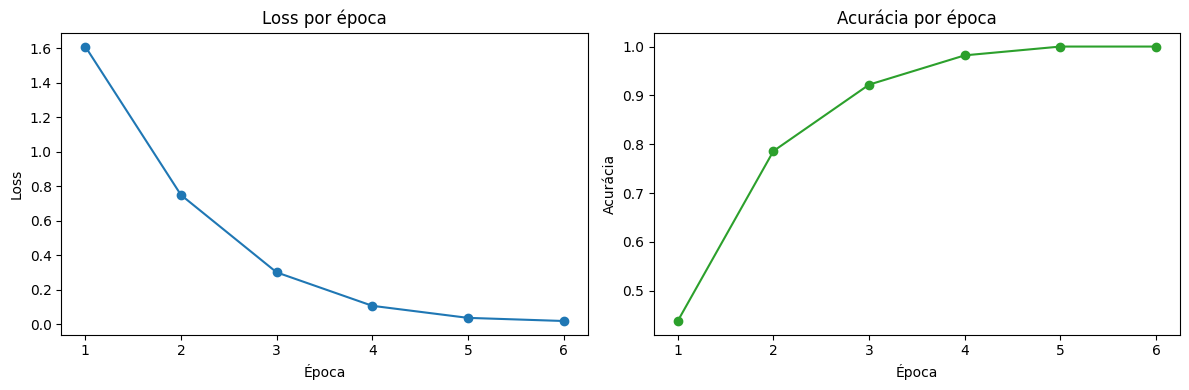

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, EPOCHS + 1), history["loss"], marker="o")
ax1.set_title("Loss por época")
ax1.set_xlabel("Época")
ax1.set_ylabel("Loss")

ax2.plot(range(1, EPOCHS + 1), history["acc"], marker="o", color="tab:green")
ax2.set_title("Acurácia por época")
ax2.set_xlabel("Época")
ax2.set_ylabel("Acurácia")

plt.tight_layout()
plt.show()


## 7. Reclusterização final (KMeans) e comparação com os pseudo-temas

Usando os embeddings da última "fotografia" (já com o fine-tuning aplicado), busca-se novamente o melhor número de clusters via silhouette score, e o resultado é comparado com os pseudo-temas usados como alvo do treinamento, através do Adjusted Rand Index (ARI).

É importante destacar que, como o modelo foi treinado justamente para prever esse pseudo-tema, é esperado que o ARI fique próximo de 1. Isso não significa que os tópicos descobertos sejam "corretos" — apenas confirma que o fine-tuning teve o efeito esperado de tornar os embeddings mais separáveis nas direções que o KMeans já havia identificado.

Em seguida, usa-se TF-IDF novamente para identificar os termos/bigramas mais característicos de cada cluster final, dando um nome legível a cada grupo de projetos.


,k,silhouette
0,3,0.423012
1,4,0.476417
2,5,0.551031
3,6,0.614883
4,7,0.648390
5,8,0.568934
6,9,0.376990
7,10,0.373361


Melhor k pelo silhouette (embeddings pós fine-tuning): 7 (esperado: próximo de 8 — o nº de pseudo-temas)


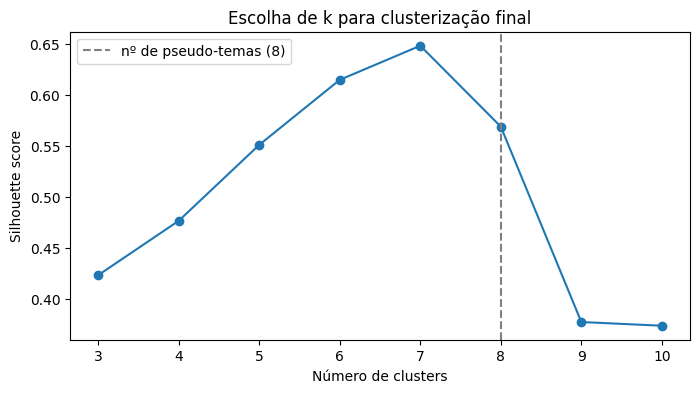

In [16]:
from sklearn.metrics import adjusted_rand_score

final_embeddings = snapshots[-1]["embeddings"]
final_pontos_2d = snapshots[-1]["pontos_2d"]

max_k_final = min(MAX_K, len(df_textos) - 1)

silhouette_results_final = []
for k in range(MIN_K, max_k_final + 1):
    kmeans_tmp = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels_tmp = kmeans_tmp.fit_predict(final_embeddings)
    score = silhouette_score(final_embeddings, labels_tmp)
    silhouette_results_final.append({"k": k, "silhouette": score})

silhouette_df_final = pd.DataFrame(silhouette_results_final)
display(silhouette_df_final)

best_k_final = int(silhouette_df_final.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Melhor k pelo silhouette (embeddings pós fine-tuning):", best_k_final,
      "(esperado: próximo de", best_k, "— o nº de pseudo-temas)")

plt.figure(figsize=(8, 4))
plt.plot(silhouette_df_final["k"], silhouette_df_final["silhouette"], marker="o")
plt.axvline(best_k, color="gray", linestyle="--", label=f"nº de pseudo-temas ({best_k})")
plt.xlabel("Número de clusters")
plt.ylabel("Silhouette score")
plt.title("Escolha de k para clusterização final")
plt.legend()
plt.show()


In [17]:
kmeans_final = KMeans(n_clusters=best_k_final, random_state=RANDOM_STATE, n_init="auto")
df_textos["cluster"] = kmeans_final.fit_predict(final_embeddings)

print("Quantidade de textos por cluster:")
display(df_textos["cluster"].value_counts().sort_index().rename_axis("cluster").reset_index(name="quantidade"))

print("\nComparação cluster final x pseudo-tema (usado no treino):")
display(pd.crosstab(df_textos["tema_pseudo_nome"], df_textos["cluster"]))

ari = adjusted_rand_score(df_textos["tema_pseudo_id"], df_textos["cluster"])
print(f"\nAdjusted Rand Index (cluster final x pseudo-tema): {ari:.3f} — próximo de 1 é o esperado (ver nota acima).")


Quantidade de textos por cluster:


,cluster,quantidade
0,0,49
1,1,175
2,2,42
3,3,96
4,4,79
5,5,28
6,6,31



Comparação cluster final x pseudo-tema (usado no treino):


cluster,0,1,2,3,4,5,6
tema_pseudo_nome,,,,,,,
desenvolver / rota / desenvolvimento,0,0,0,0,0,0,31
desenvolvimento / processo / ao,0,0,0,0,79,0,0
desenvolvimento / projeto / producao,0,0,34,0,0,0,0
es / medic / ncia,0,0,8,0,0,0,0
producao / tratamento / controle,49,0,0,0,0,0,0
projeto / desenvolvimento / sistema,0,175,0,0,0,0,0
sistema / desenvolvimento / armazenamento energia,0,0,0,0,0,28,0
software / plataforma / desenvolvimento,0,0,0,96,0,0,0



Adjusted Rand Index (cluster final x pseudo-tema): 0.993 — próximo de 1 é o esperado (ver nota acima).


**Termos representativos de cada cluster final.** Mesma lógica da seção 5: usamos TF-IDF
para identificar quais palavras/bigramas mais caracterizam cada cluster encontrado após
o fine-tuning — útil para dar um nome legível a cada grupo final de projetos.


In [18]:
tfidf_matrix_final = vectorizer_topicos.transform(df_textos["texto"])
terms_final = terms_topicos  # vocabulário já ajustado na seção 5

cluster_terms = []
for cluster_id in sorted(df_textos["cluster"].unique()):
    indices = df_textos.index[df_textos["cluster"] == cluster_id].tolist()
    mean_tfidf = np.asarray(tfidf_matrix_final[indices].mean(axis=0)).ravel()
    top_indices = mean_tfidf.argsort()[::-1][:10]
    cluster_terms.append({
        "cluster": cluster_id,
        "termos_representativos": ", ".join(terms_final[top_indices]),
        "quantidade_textos": len(indices),
    })

cluster_terms_df = pd.DataFrame(cluster_terms)
display(cluster_terms_df)


,cluster,termos_representativos,quantidade_textos
0,0,"producao, tratamento, controle, partir, pragas...",49
1,1,"projeto, desenvolvimento, sistema, dados, obje...",175
2,2,"desenvolvimento, projeto, es, sistema, produca...",42
3,3,"software, plataforma, desenvolvimento, sistema...",96
4,4,"desenvolvimento, processo, ao, producao, mater...",79
5,5,"sistema, desenvolvimento, armazenamento energi...",28
6,6,"desenvolver, rota, desenvolvimento, rota tecno...",31


### Visualização final dos clusters (PCA e t-SNE)

Compara lado a lado duas formas de reduzir os embeddings finais para 2D — PCA (linear) e
t-SNE (não-linear) — coloridas pelos clusters encontrados pelo KMeans, para checar se os
agrupamentos fazem sentido visualmente sob as duas técnicas.


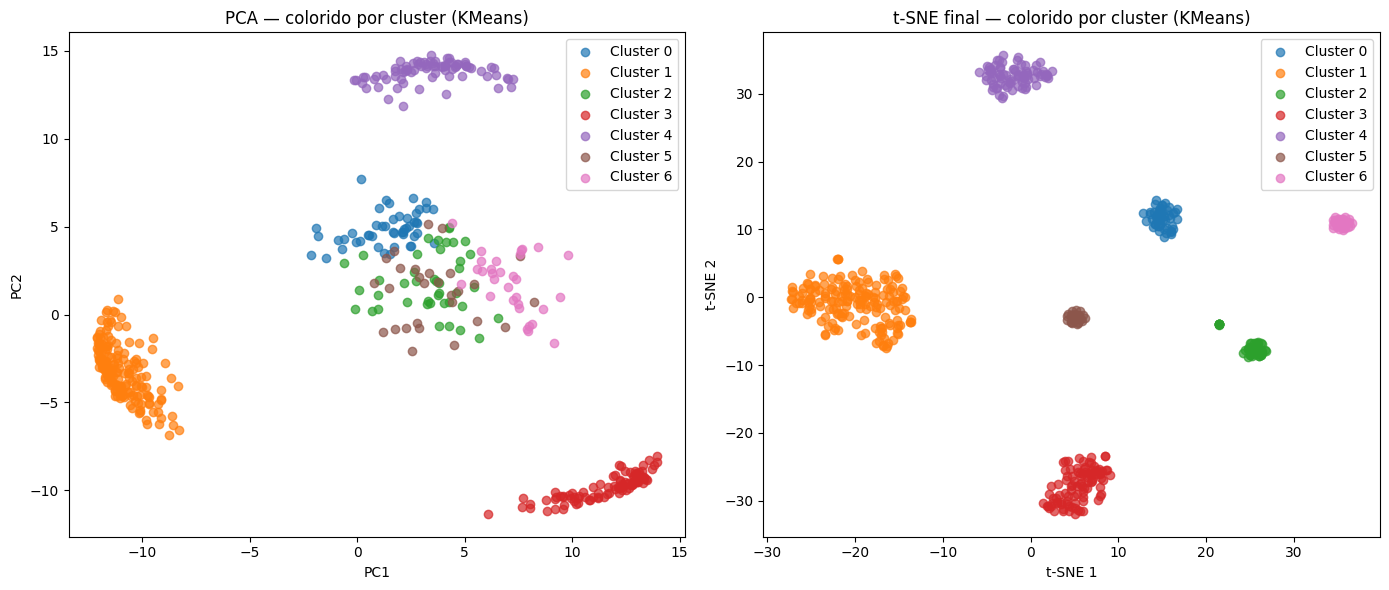

In [19]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=RANDOM_STATE)
pontos_pca = pca.fit_transform(final_embeddings)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for cluster_id in sorted(df_textos["cluster"].unique()):
    mascara = df_textos["cluster"] == cluster_id
    ax1.scatter(pontos_pca[mascara, 0], pontos_pca[mascara, 1], label=f"Cluster {cluster_id}", alpha=0.7)
ax1.set_title("PCA — colorido por cluster (KMeans)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.legend()

for cluster_id in sorted(df_textos["cluster"].unique()):
    mascara = df_textos["cluster"] == cluster_id
    ax2.scatter(final_pontos_2d[mascara, 0], final_pontos_2d[mascara, 1], label=f"Cluster {cluster_id}", alpha=0.7)
ax2.set_title("t-SNE final — colorido por cluster (KMeans)")
ax2.set_xlabel("t-SNE 1")
ax2.set_ylabel("t-SNE 2")
ax2.legend()

plt.tight_layout()
plt.show()


## 8. Exportação dos resultados

Exporta três arquivos CSV, equivalentes aos do notebook original: o dataset com os
pseudo-temas e clusters finais, as entidades nomeadas extraídas pelo spaCy, e os termos
representativos de cada cluster.


In [20]:
output_dataset_path = "textos_cientificos_temas_clusters.csv"
output_entities_path = "textos_cientificos_entidades_nomeadas.csv"
output_cluster_terms_path = "textos_cientificos_termos_clusters.csv"

df_textos.to_csv(output_dataset_path, index=False, encoding=OUTPUT_ENCODING)
df_entidades.to_csv(output_entities_path, index=False, encoding=OUTPUT_ENCODING)
cluster_terms_df.to_csv(output_cluster_terms_path, index=False, encoding=OUTPUT_ENCODING)

print("Arquivos exportados:")
print("-", output_dataset_path)
print("-", output_entities_path)
print("-", output_cluster_terms_path)


Arquivos exportados:
- textos_cientificos_temas_clusters.csv
- textos_cientificos_entidades_nomeadas.csv
- textos_cientificos_termos_clusters.csv
